In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/anuragpanchal/Documents/MachineLearning/KMeans-Cricket/purchasing.csv",encoding='latin')

In [4]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [6]:
df.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5225)

In [12]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [17]:
df_copy = df.copy()

In [18]:
df_copy

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [20]:
df_copy.drop(columns='CustomerID',inplace=True)

In [21]:
df_copy

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,France


In [23]:
df_copy.drop(columns=['InvoiceNo','StockCode','Description'],inplace=True)

In [24]:
df_copy

,Quantity,InvoiceDate,UnitPrice,Country
0,6,12/1/2010 8:26,2.55,United Kingdom
1,6,12/1/2010 8:26,3.39,United Kingdom
2,8,12/1/2010 8:26,2.75,United Kingdom
3,6,12/1/2010 8:26,3.39,United Kingdom
4,6,12/1/2010 8:26,3.39,United Kingdom
...,...,...,...,...
541904,12,12/9/2011 12:50,0.85,France
541905,6,12/9/2011 12:50,2.10,France
541906,4,12/9/2011 12:50,4.15,France
541907,4,12/9/2011 12:50,4.15,France


In [30]:
df_copy['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])

In [31]:
df_copy

,Quantity,InvoiceDate,UnitPrice,Country
0,6,2010-12-01 08:26:00,2.55,United Kingdom
1,6,2010-12-01 08:26:00,3.39,United Kingdom
2,8,2010-12-01 08:26:00,2.75,United Kingdom
3,6,2010-12-01 08:26:00,3.39,United Kingdom
4,6,2010-12-01 08:26:00,3.39,United Kingdom
...,...,...,...,...
541904,12,2011-12-09 12:50:00,0.85,France
541905,6,2011-12-09 12:50:00,2.10,France
541906,4,2011-12-09 12:50:00,4.15,France
541907,4,2011-12-09 12:50:00,4.15,France


In [38]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Quantity     401604 non-null  int64         
 1   InvoiceDate  401604 non-null  datetime64[ns]
 2   UnitPrice    401604 non-null  float64       
 3   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 15.3+ MB


In [40]:
df_copy['year'] = df_copy['InvoiceDate'].dt.year
df_copy['month'] = df_copy['InvoiceDate'].dt.month
df_copy['day'] = df_copy['InvoiceDate'].dt.day
df_copy['hour'] = df_copy['InvoiceDate'].dt.hour


In [44]:
df_copy = pd.get_dummies(df_copy,columns=['Country'],drop_first=True)

In [47]:
df_copy.drop(columns='InvoiceDate',inplace=True)

In [48]:
df_copy

,Quantity,UnitPrice,year,month,day,hour,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,6,2.55,2010,12,1,8,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,6,3.39,2010,12,1,8,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,8,2.75,2010,12,1,8,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,3.39,2010,12,1,8,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,6,3.39,2010,12,1,8,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,12,0.85,2011,12,9,12,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
541905,6,2.10,2011,12,9,12,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
541906,4,4.15,2011,12,9,12,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
541907,4,4.15,2011,12,9,12,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [49]:
from sklearn.preprocessing import StandardScaler

In [51]:
sc = StandardScaler()

df_scaled = sc.fit_transform(df_copy)

In [52]:
df_scaled

array([[-2.47051512e-02, -1.32455755e-02, -3.77343679e+00, ...,
        -1.30134429e-02,  3.54681446e-01, -2.45041620e-02],
       [-2.47051512e-02, -1.20497251e-03, -3.77343679e+00, ...,
        -1.30134429e-02,  3.54681446e-01, -2.45041620e-02],
       [-1.67141882e-02, -1.03787652e-02, -3.77343679e+00, ...,
        -1.30134429e-02,  3.54681446e-01, -2.45041620e-02],
       ...,
       [-3.26961142e-02,  9.68890634e-03,  2.65010402e-01, ...,
        -1.30134429e-02, -2.81943138e+00, -2.45041620e-02],
       [-3.26961142e-02,  9.68890634e-03,  2.65010402e-01, ...,
        -1.30134429e-02, -2.81943138e+00, -2.45041620e-02],
       [-3.66915957e-02,  2.11561472e-02,  2.65010402e-01, ...,
        -1.30134429e-02, -2.81943138e+00, -2.45041620e-02]])

In [53]:
df_scaled = pd.DataFrame(df_scaled,columns=df_copy.columns)

In [54]:
df_scaled

,Quantity,UnitPrice,year,month,day,hour,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,-0.024705,-0.013246,-3.773437,1.288855,-1.622469,-2.067570,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,0.354681,-0.024504
1,-0.024705,-0.001205,-3.773437,1.288855,-1.622469,-2.067570,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,0.354681,-0.024504
2,-0.016714,-0.010379,-3.773437,1.288855,-1.622469,-2.067570,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,0.354681,-0.024504
3,-0.024705,-0.001205,-3.773437,1.288855,-1.622469,-2.067570,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,0.354681,-0.024504
4,-0.024705,-0.001205,-3.773437,1.288855,-1.622469,-2.067570,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,0.354681,-0.024504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401599,-0.000732,-0.037613,0.265010,1.288855,-0.697895,-0.319478,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,-2.819431,-0.024504
401600,-0.024705,-0.019696,0.265010,1.288855,-0.697895,-0.319478,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,-2.819431,-0.024504
401601,-0.032696,0.009689,0.265010,1.288855,-0.697895,-0.319478,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,-2.819431,-0.024504
401602,-0.032696,0.009689,0.265010,1.288855,-0.697895,-0.319478,-0.031615,-0.006506,-0.071962,-0.008927,...,-0.012018,-0.00499,-0.023886,-0.07959,-0.0339,-0.068525,-0.026928,-0.013013,-2.819431,-0.024504


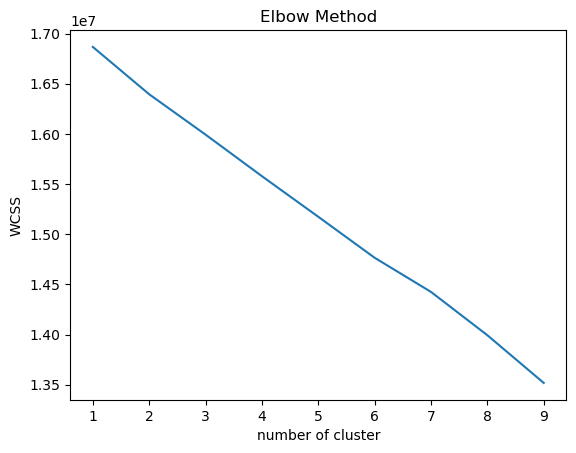

In [61]:
from sklearn.cluster import KMeans
k_values = [1,2,3,4,5,6,7,8,9]
wcss = []

for i in k_values:
    model = KMeans(n_clusters=i,random_state=42,max_iter=100)
    model.fit(df_scaled)
    wcss.append(model.inertia_)


plt.plot(k_values,wcss)
plt.xlabel("number of cluster")
plt.ylabel('WCSS')
plt.title("Elbow Method")
plt.show()

In [62]:
model2 = KMeans(n_clusters=6,random_state=42,max_iter=100)
model2.fit(df_scaled)
model2.labels_

array([1, 1, 1, ..., 0, 0, 0], dtype=int32)

In [64]:
df['clusterID'] = model2.labels_

In [69]:
group1 = df[df['clusterID']==0]
group2 = df[df['clusterID']==1]
group3 = df[df['clusterID']==2]
group4 = df[df['clusterID']==3]
group5 = df[df['clusterID']==4]
group6 = df[df['clusterID']==5]

In [66]:
group1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,group,clusterID
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,12/1/2010 8:45,3.75,12583.0,France,0,0
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,12/1/2010 8:45,3.75,12583.0,France,0,0
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,12/1/2010 8:45,3.75,12583.0,France,0,0
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,12/1/2010 8:45,0.85,12583.0,France,0,0
30,536370,21883,STARS GIFT TAPE,24,12/1/2010 8:45,0.65,12583.0,France,0,0
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,0,0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,0,0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,0,0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,0,0


In [67]:
group2

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,group,clusterID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,1,1
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,1,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1,1
...,...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,12/9/2011 12:31,1.95,15804.0,United Kingdom,1,1
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,12/9/2011 12:49,2.95,13113.0,United Kingdom,1,1
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,12/9/2011 12:49,1.25,13113.0,United Kingdom,1,1
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,12/9/2011 12:49,8.95,13113.0,United Kingdom,1,1


In [68]:
group3

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,group,clusterID
72985,542276,82551,LAUNDRY 15C METAL SIGN,12,1/27/2011 10:19,1.45,12764.0,Lebanon,2,2
72986,542276,21165,BEWARE OF THE CAT METAL SIGN,12,1/27/2011 10:19,1.69,12764.0,Lebanon,2,2
72987,542276,82600,NO SINGING METAL SIGN,12,1/27/2011 10:19,2.10,12764.0,Lebanon,2,2
72988,542276,21754,HOME BUILDING BLOCK WORD,6,1/27/2011 10:19,5.95,12764.0,Lebanon,2,2
72989,542276,21756,BATH BUILDING BLOCK WORD,6,1/27/2011 10:19,5.95,12764.0,Lebanon,2,2
72990,542276,82482,WOODEN PICTURE FRAME WHITE FINISH,6,1/27/2011 10:19,2.55,12764.0,Lebanon,2,2
72991,542276,82494L,WOODEN FRAME ANTIQUE WHITE,6,1/27/2011 10:19,2.95,12764.0,Lebanon,2,2
72992,542276,22169,FAMILY ALBUM WHITE PICTURE FRAME,4,1/27/2011 10:19,8.50,12764.0,Lebanon,2,2
72993,542276,47566,PARTY BUNTING,15,1/27/2011 10:19,4.65,12764.0,Lebanon,2,2
72994,542276,82484,WOOD BLACK BOARD ANT WHITE FINISH,3,1/27/2011 10:19,6.45,12764.0,Lebanon,2,2


In [70]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,group,clusterID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,1,1
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,1,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1,1
